# SECTION 1 — Imports & Setup

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import joblib

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 100)

# SECTION 2 — Load Clean Datasets From CSV

In [39]:
pima_clean = pd.read_csv("../data/pima_clean.csv")
nhanes_clean = pd.read_csv("../data/nhanes_clean.csv")

print("PIMA:", pima_clean.shape)
print("NHANES:", nhanes_clean.shape)

pima_clean.head(), nhanes_clean.head()

PIMA: (768, 9)
NHANES: (10761, 12)


(   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 0            6    148.0           72.0           35.0    125.0  33.6   
 1            1     85.0           66.0           29.0    125.0  26.6   
 2            8    183.0           64.0           29.0    125.0  23.3   
 3            1     89.0           66.0           23.0     94.0  28.1   
 4            0    137.0           40.0           35.0    168.0  43.1   
 
    DiabetesPedigreeFunction  Age  Outcome  
 0                     0.627   50        1  
 1                     0.351   31        0  
 2                     0.672   32        1  
 3                     0.167   21        0  
 4                     2.288   33        1  ,
       SEQN  RIAGENDR  RIDAGEYR  INDFMPIR  BMXBMI  LBXGH  LBXGLU  \
 0  62161.0       0.0      22.0      3.15    23.3    5.1    92.0   
 1  62164.0       1.0      44.0      1.67    23.2    4.9    82.0   
 2  62165.0       1.0      14.0      0.57    27.2    5.9    88.0   
 3  62169.0      

# SECTION 3 — Prepare X and y

## PIMA

In [40]:
X_pima = pima_clean.drop("Outcome", axis=1)
y_pima = pima_clean["Outcome"]

## NHANES

In [41]:
X_nhanes = nhanes_clean.drop("diabetes_label", axis=1)
y_nhanes = nhanes_clean["diabetes_label"]

print("X_nhanes shape:", X_nhanes.shape)
print("y_nhanes value counts:\n", y_nhanes.value_counts())

X_nhanes shape: (10761, 11)
y_nhanes value counts:
 diabetes_label
0.0    9501
1.0    1260
Name: count, dtype: int64


# SECTION 4 — Train-Test Split + Scaling

## PIMA

In [42]:
X_pima_train, X_pima_test, y_pima_train, y_pima_test = train_test_split(
    X_pima, y_pima, test_size=0.2, random_state=42, stratify=y_pima
)

pima_scaler = StandardScaler()
X_pima_train_scaled = pima_scaler.fit_transform(X_pima_train)
X_pima_test_scaled = pima_scaler.transform(X_pima_test)

# Save scaler for Streamlit later
joblib.dump(pima_scaler, "../models/pima_scaler.pkl")

['../models/pima_scaler.pkl']

## NHANES

In [43]:
X_nhanes_train, X_nhanes_test, y_nhanes_train, y_nhanes_test = train_test_split(
    X_nhanes, y_nhanes,
    test_size=0.2,
    random_state=42,
    stratify=y_nhanes
)

scaler_nhanes = StandardScaler()
X_nhanes_train_scaled = scaler_nhanes.fit_transform(X_nhanes_train)
X_nhanes_test_scaled = scaler_nhanes.transform(X_nhanes_test)

joblib.dump(scaler_nhanes, "../models/nhanes_scaler.pkl")
print("Saved NHANES scaler to ../models/nhanes_scaler.pkl")

Saved NHANES scaler to ../models/nhanes_scaler.pkl


# SECTION 5 — Helper Evaluation Functions

In [44]:
def plot_roc_curve(y_test, y_proba, title):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
    plt.plot([0,1],[0,1],'k--')
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


def plot_confusion(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print(f"\n===== {model_name} =====")
    print(classification_report(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_proba))

    plot_roc_curve(y_test, y_proba, f"{model_name} ROC Curve")
    plot_confusion(y_test, y_pred, f"{model_name} Confusion Matrix")

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba)
    }

# SECTION 6 — MODEL TRAINING (PIMA)

## Logistic Regression


===== PIMA – Logistic Regression =====
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

AUC: 0.812962962962963


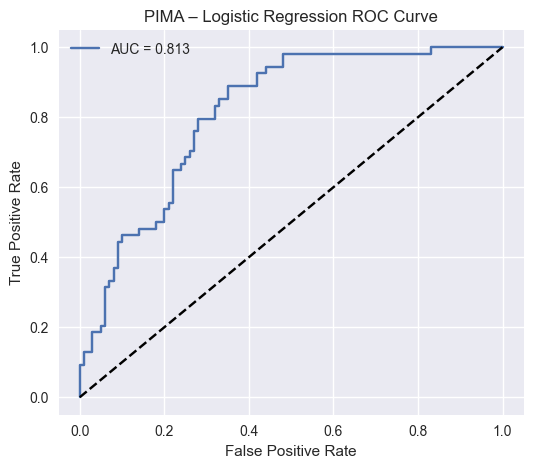

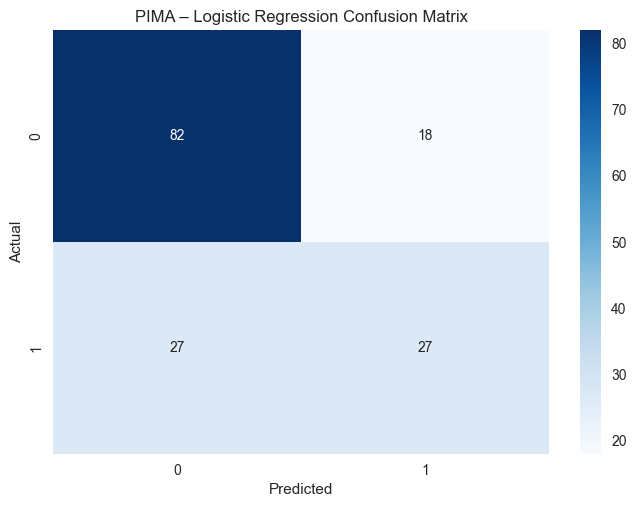

['../models/pima_logreg.pkl']

In [45]:
logreg_pima = LogisticRegression(max_iter=2000)
logreg_pima.fit(X_pima_train_scaled, y_pima_train)

results_pima_lr = evaluate_model(
    logreg_pima, X_pima_test_scaled, y_pima_test,
    "PIMA – Logistic Regression"
)

joblib.dump(logreg_pima, "../models/pima_logreg.pkl")

## Random Forest


===== PIMA – Random Forest =====
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       100
           1       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154

AUC: 0.8170370370370371


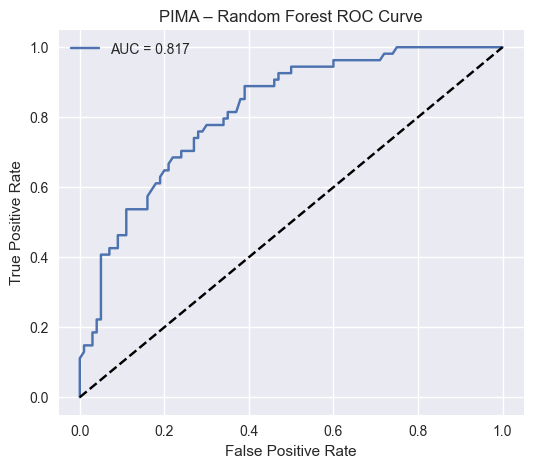

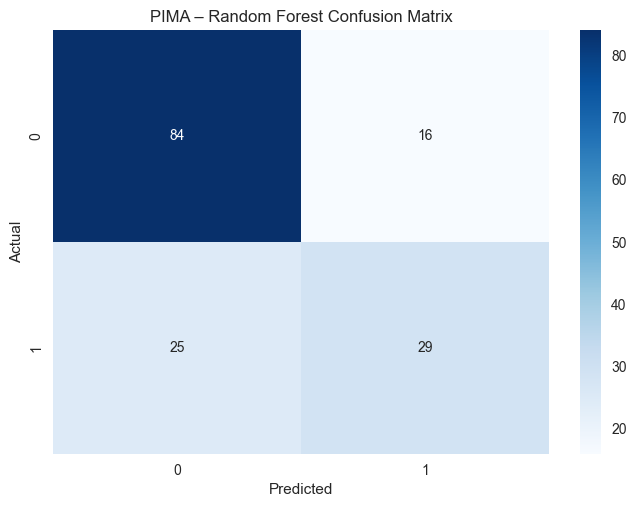

['../models/pima_rf.pkl']

In [46]:
rf_pima = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf_pima.fit(X_pima_train_scaled, y_pima_train)

results_pima_rf = evaluate_model(
    rf_pima, X_pima_test_scaled, y_pima_test,
    "PIMA – Random Forest"
)

joblib.dump(rf_pima, "../models/pima_rf.pkl")

## XGBoost


===== PIMA – XGBoost =====
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       100
           1       0.69      0.65      0.67        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.75       154
weighted avg       0.77      0.77      0.77       154

AUC: 0.8188888888888889


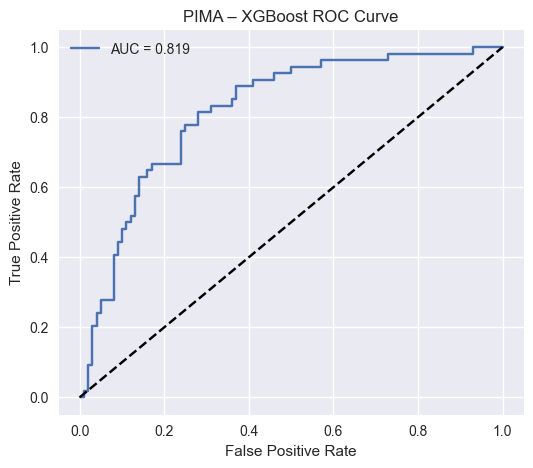

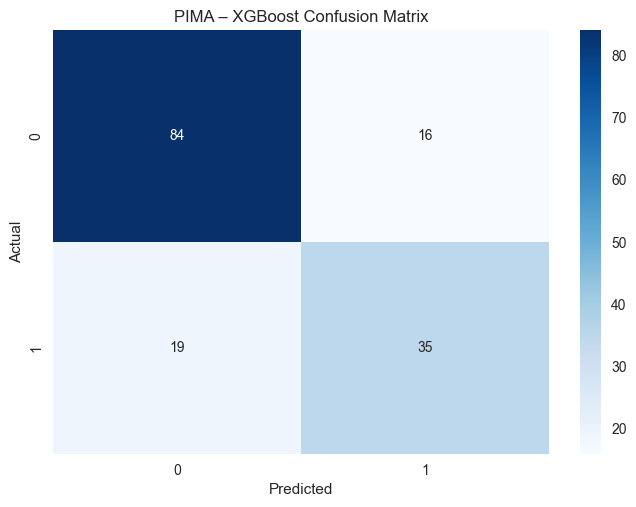

['../models/pima_xgb.pkl']

In [47]:
xgb_pima = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)

xgb_pima.fit(X_pima_train_scaled, y_pima_train)

results_pima_xgb = evaluate_model(
    xgb_pima, X_pima_test_scaled, y_pima_test,
    "PIMA – XGBoost"
)

joblib.dump(xgb_pima, "../models/pima_xgb.pkl")

## ANN (MLP Classifier)


===== PIMA – ANN =====
              precision    recall  f1-score   support

           0       0.76      0.81      0.79       100
           1       0.60      0.54      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.68       154
weighted avg       0.71      0.71      0.71       154

AUC: 0.8175925925925926


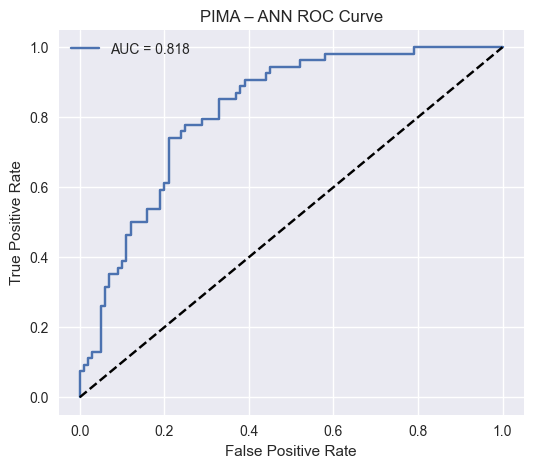

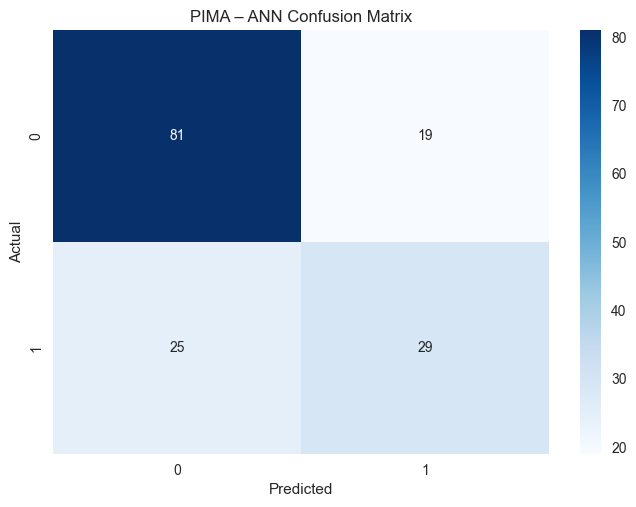

['../models/pima_ann.pkl']

In [48]:
ann_pima = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    early_stopping=True,
    max_iter=1000,
    random_state=42
)

ann_pima.fit(X_pima_train_scaled, y_pima_train)

results_pima_ann = evaluate_model(
    ann_pima, X_pima_test_scaled, y_pima_test,
    "PIMA – ANN"
)

joblib.dump(ann_pima, "../models/pima_ann.pkl")

# SECTION 7 — MODEL TRAINING (NHANES)

## Logistic Regression


===== NHANES – Logistic Regression =====
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96      1901
         1.0       0.84      0.48      0.61       252

    accuracy                           0.93      2153
   macro avg       0.89      0.74      0.79      2153
weighted avg       0.92      0.93      0.92      2153

AUC: 0.942795354157795


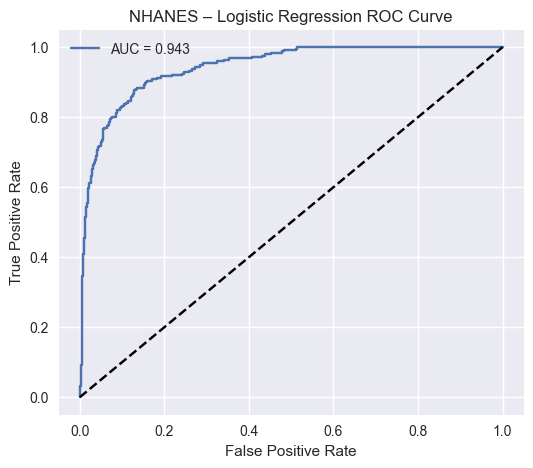

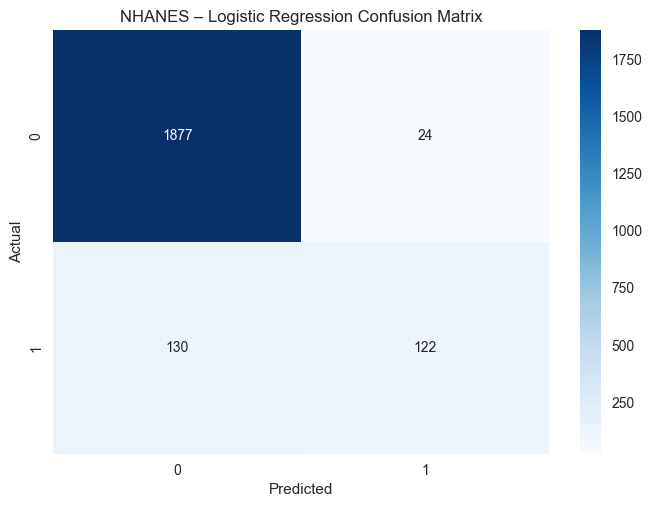

Saved NHANES Logistic Regression model.


In [49]:
from sklearn.linear_model import LogisticRegression

logreg_nhanes = LogisticRegression(max_iter=2000)
logreg_nhanes.fit(X_nhanes_train_scaled, y_nhanes_train)

results_nhanes_lr = evaluate_model(
    logreg_nhanes,
    X_nhanes_test_scaled,
    y_nhanes_test,
    "NHANES – Logistic Regression"
)

joblib.dump(logreg_nhanes, "../models/nhanes_logreg.pkl")
print("Saved NHANES Logistic Regression model.")

## Random Forest


===== NHANES – Random Forest =====
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97      1901
         1.0       0.80      0.63      0.71       252

    accuracy                           0.94      2153
   macro avg       0.87      0.81      0.84      2153
weighted avg       0.93      0.94      0.94      2153

AUC: 0.9379002696993228


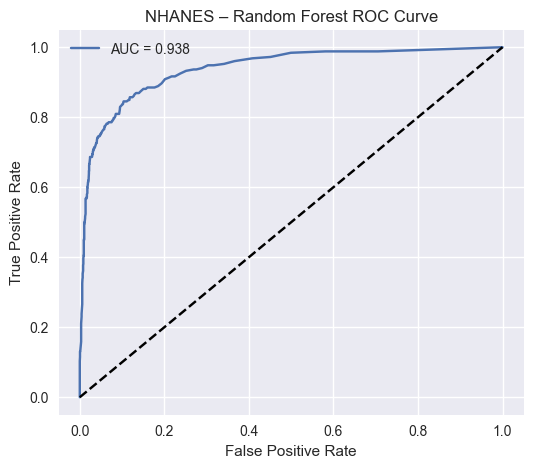

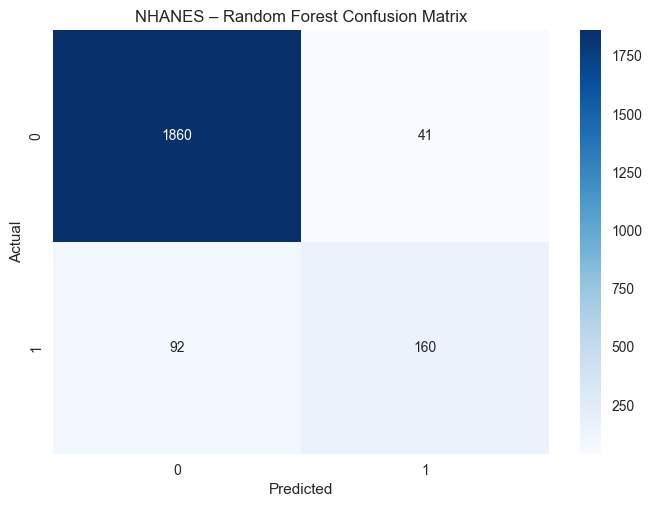

Saved NHANES Random Forest model.


In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_nhanes = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf_nhanes.fit(X_nhanes_train_scaled, y_nhanes_train)

results_nhanes_rf = evaluate_model(
    rf_nhanes,
    X_nhanes_test_scaled,
    y_nhanes_test,
    "NHANES – Random Forest"
)

joblib.dump(rf_nhanes, "../models/nhanes_rf.pkl")
print("Saved NHANES Random Forest model.")

## XGBoost


===== NHANES – XGBoost =====
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96      1901
         1.0       0.77      0.63      0.69       252

    accuracy                           0.93      2153
   macro avg       0.86      0.80      0.83      2153
weighted avg       0.93      0.93      0.93      2153

AUC: 0.9394867363042008


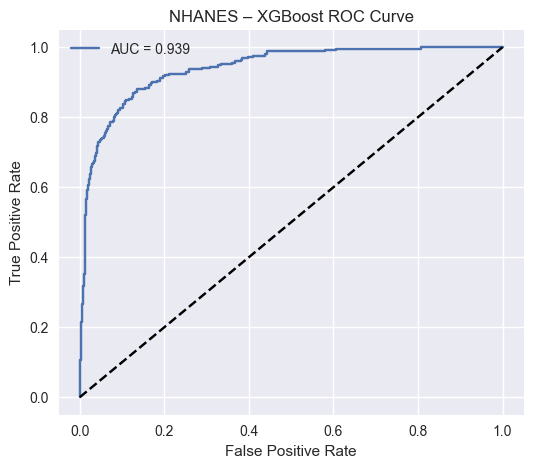

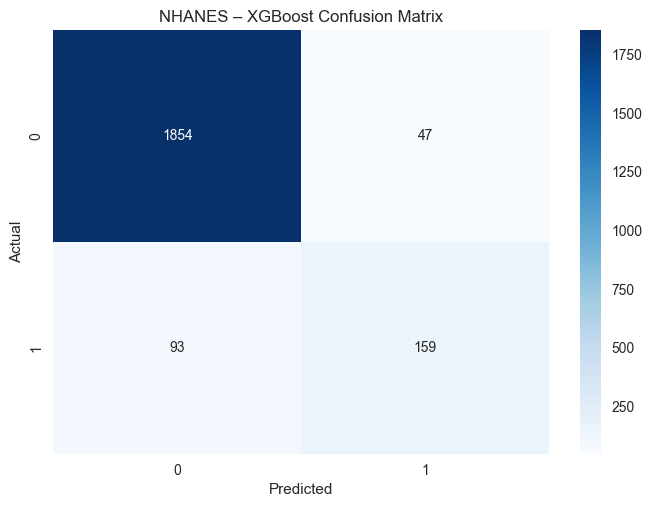

Saved NHANES XGBoost model.


In [51]:
import xgboost as xgb

xgb_nhanes = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

xgb_nhanes.fit(X_nhanes_train_scaled, y_nhanes_train)

results_nhanes_xgb = evaluate_model(
    xgb_nhanes,
    X_nhanes_test_scaled,
    y_nhanes_test,
    "NHANES – XGBoost"
)

joblib.dump(xgb_nhanes, "../models/nhanes_xgb.pkl")
print("Saved NHANES XGBoost model.")

## ANN (MLP Classifier)


===== NHANES – ANN =====
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96      1901
         1.0       0.81      0.57      0.67       252

    accuracy                           0.93      2153
   macro avg       0.88      0.78      0.82      2153
weighted avg       0.93      0.93      0.93      2153

AUC: 0.9407183353790404


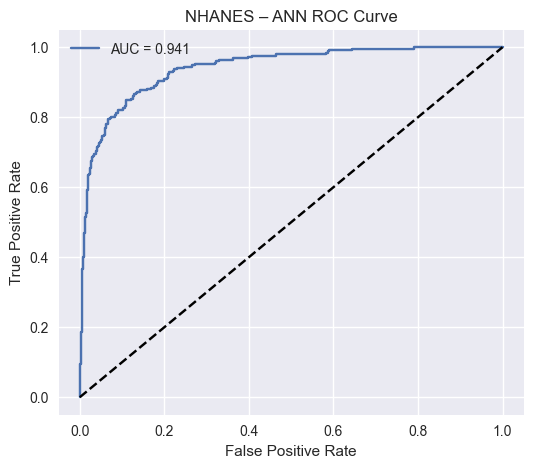

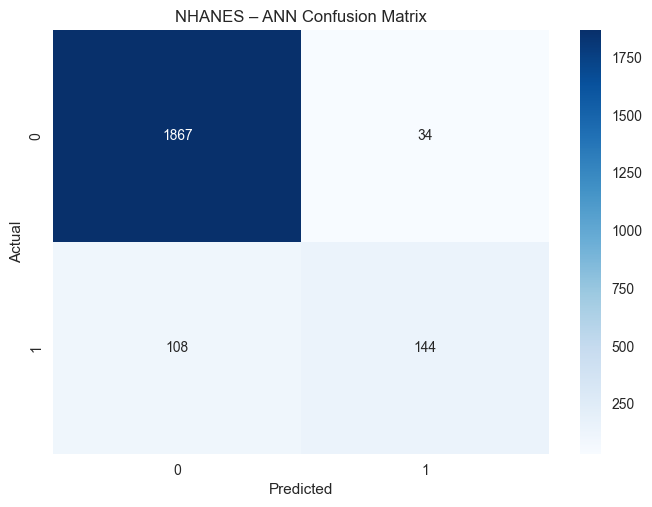

Saved NHANES ANN model.


In [52]:
from sklearn.neural_network import MLPClassifier

ann_nhanes = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=800,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42
)

ann_nhanes.fit(X_nhanes_train_scaled, y_nhanes_train)

results_nhanes_ann = evaluate_model(
    ann_nhanes,
    X_nhanes_test_scaled,
    y_nhanes_test,
    "NHANES – ANN"
)

joblib.dump(ann_nhanes, "../models/nhanes_ann.pkl")
print("Saved NHANES ANN model.")

# SECTION 8 — MODEL COMPARISON TABLES

## PIMA Summary

In [53]:
pima_results = pd.DataFrame([
    results_pima_lr,
    results_pima_rf,
    results_pima_xgb,
    results_pima_ann
])

pima_results

,model,accuracy,f1,auc
0,PIMA – Logistic Regression,0.707792,0.545455,0.812963
1,PIMA – Random Forest,0.733766,0.585859,0.817037
2,PIMA – XGBoost,0.772727,0.666667,0.818889
3,PIMA – ANN,0.714286,0.568627,0.817593


## NHANES Summary

In [54]:
nhanes_results = pd.DataFrame([
    results_nhanes_lr,
    results_nhanes_rf,
    results_nhanes_xgb,
    results_nhanes_ann
])

nhanes_results

,model,accuracy,f1,auc
0,NHANES – Logistic Regression,0.928472,0.613065,0.942795
1,NHANES – Random Forest,0.938226,0.706402,0.937900
2,NHANES – XGBoost,0.934974,0.694323,0.939487
3,NHANES – ANN,0.934046,0.669767,0.940718


## SAVE

In [55]:
nhanes_results.to_csv("../models/nhanes_model_scores.csv", index=False)
print("Saved NHANES model scores to ../models/nhanes_model_scores.csv")

Saved NHANES model scores to ../models/nhanes_model_scores.csv


# NHANES – Hyperparameter Tuning

## Imports for tuning

In [56]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import joblib

## Logistic Regression – NHANES Tuning

Best Logistic Regression params (NHANES): {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2'}

===== NHANES – Logistic Regression (Tuned) =====
              precision    recall  f1-score   support

         0.0       0.98      0.89      0.93      1901
         1.0       0.50      0.83      0.63       252

    accuracy                           0.88      2153
   macro avg       0.74      0.86      0.78      2153
weighted avg       0.92      0.88      0.90      2153

AUC: 0.943803595434316


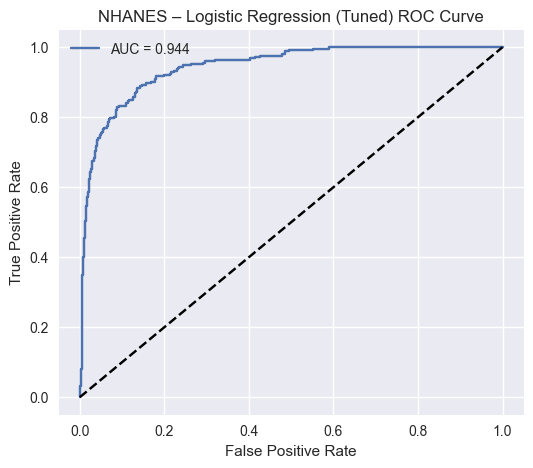

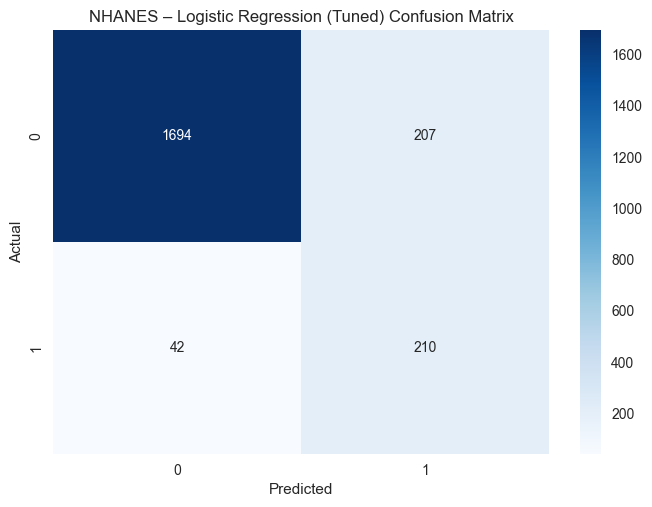

['../models/nhanes_logreg_tuned.pkl']

In [57]:
# Base model
lr_nh = LogisticRegression(
    max_iter=5000,
    solver="liblinear"  # works well with class_weight & small-ish data
)

# Search space
lr_param_grid_nh = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"],
    "penalty": ["l2"]
}

# Grid search
lr_search_nh = GridSearchCV(
    lr_nh,
    lr_param_grid_nh,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

lr_search_nh.fit(X_nhanes_train_scaled, y_nhanes_train)
best_lr_nh = lr_search_nh.best_estimator_
print("Best Logistic Regression params (NHANES):", lr_search_nh.best_params_)

# Evaluate tuned LR
results_nhanes_lr_tuned = evaluate_model(
    best_lr_nh,
    X_nhanes_test_scaled,
    y_nhanes_test,
    "NHANES – Logistic Regression (Tuned)"
)

# Save
joblib.dump(best_lr_nh, "../models/nhanes_logreg_tuned.pkl")

## Random Forest – NHANES Tuning

Best Random Forest params (NHANES): {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}

===== NHANES – Random Forest (Tuned) =====
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97      1901
         1.0       0.80      0.65      0.72       252

    accuracy                           0.94      2153
   macro avg       0.88      0.81      0.84      2153
weighted avg       0.94      0.94      0.94      2153

AUC: 0.9439935539356897


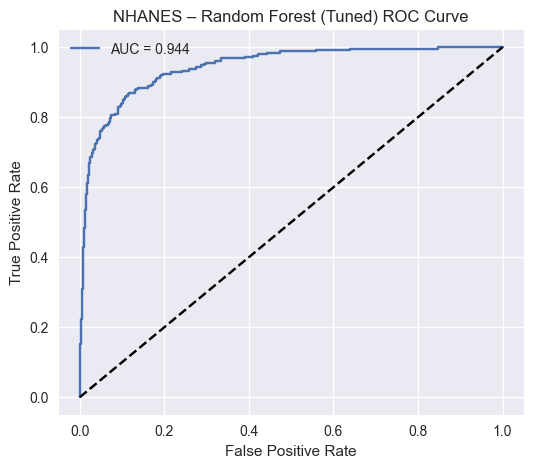

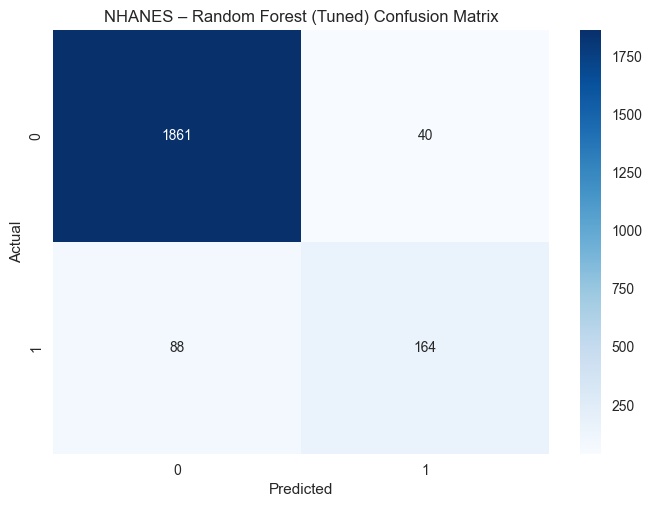

['../models/nhanes_rf_tuned.pkl']

In [58]:
rf_nh = RandomForestClassifier(random_state=42)

rf_param_dist_nh = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search_nh = RandomizedSearchCV(
    rf_nh,
    rf_param_dist_nh,
    n_iter=25,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=42
)

rf_search_nh.fit(X_nhanes_train_scaled, y_nhanes_train)
best_rf_nh = rf_search_nh.best_estimator_
print("Best Random Forest params (NHANES):", rf_search_nh.best_params_)

results_nhanes_rf_tuned = evaluate_model(
    best_rf_nh,
    X_nhanes_test_scaled,
    y_nhanes_test,
    "NHANES – Random Forest (Tuned)"
)

joblib.dump(best_rf_nh, "../models/nhanes_rf_tuned.pkl")

## XGBoost – NHANES Tuning

C:\Users\windows 11\.conda\envs\diabetes-ml\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:18:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost params (NHANES): {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

===== NHANES – XGBoost (Tuned) =====
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      1901
         1.0       0.80      0.65      0.72       252

    accuracy                           0.94      2153
   macro avg       0.88      0.82      0.84      2153
weighted avg       0.94      0.94      0.94      2153

AUC: 0.9469243422425958


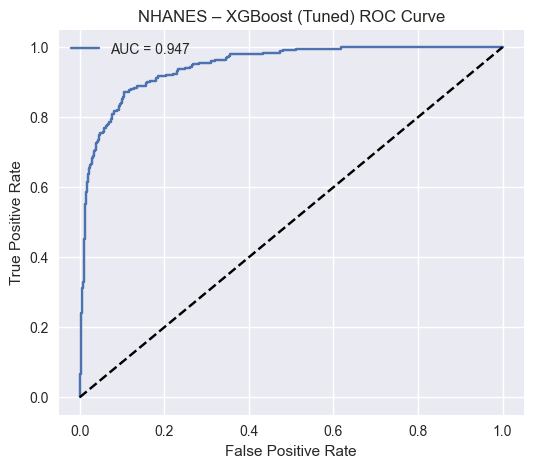

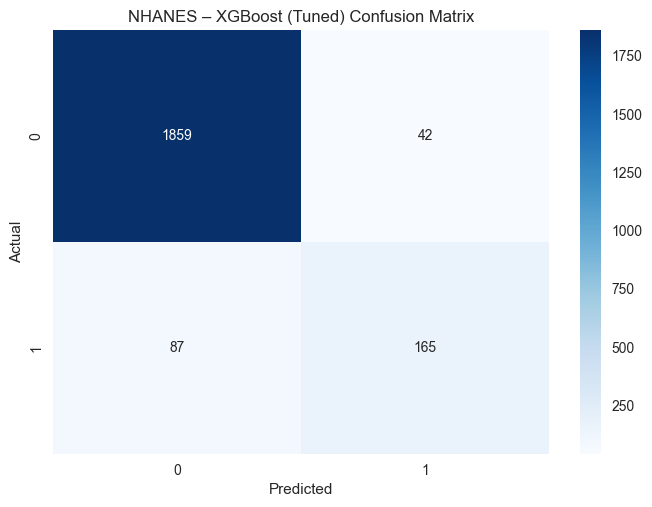

['../models/nhanes_xgb_tuned.pkl']

In [59]:
xgb_nh = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

xgb_param_dist_nh = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

xgb_search_nh = RandomizedSearchCV(
    xgb_nh,
    xgb_param_dist_nh,
    n_iter=25,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=42
)

xgb_search_nh.fit(X_nhanes_train_scaled, y_nhanes_train)
best_xgb_nh = xgb_search_nh.best_estimator_
print("Best XGBoost params (NHANES):", xgb_search_nh.best_params_)

results_nhanes_xgb_tuned = evaluate_model(
    best_xgb_nh,
    X_nhanes_test_scaled,
    y_nhanes_test,
    "NHANES – XGBoost (Tuned)"
)

joblib.dump(best_xgb_nh, "../models/nhanes_xgb_tuned.pkl")

## ANN (MLPClassifier) – NHANES Tuning

Best ANN params (NHANES): {'learning_rate_init': 0.0005, 'hidden_layer_sizes': (32,), 'batch_size': 32, 'alpha': 0.01}

===== NHANES – ANN (Tuned) =====
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97      1901
         1.0       0.80      0.63      0.70       252

    accuracy                           0.94      2153
   macro avg       0.88      0.80      0.83      2153
weighted avg       0.93      0.94      0.93      2153

AUC: 0.9442169117340081


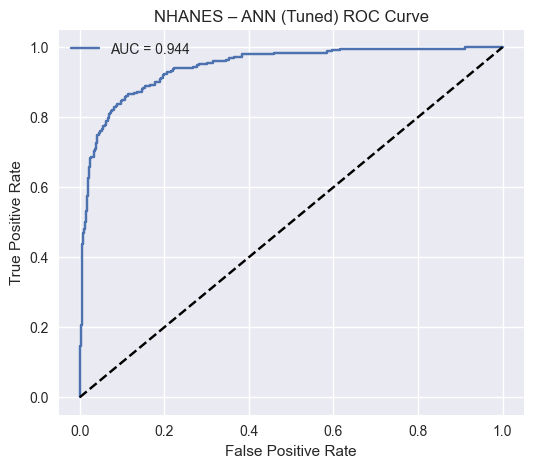

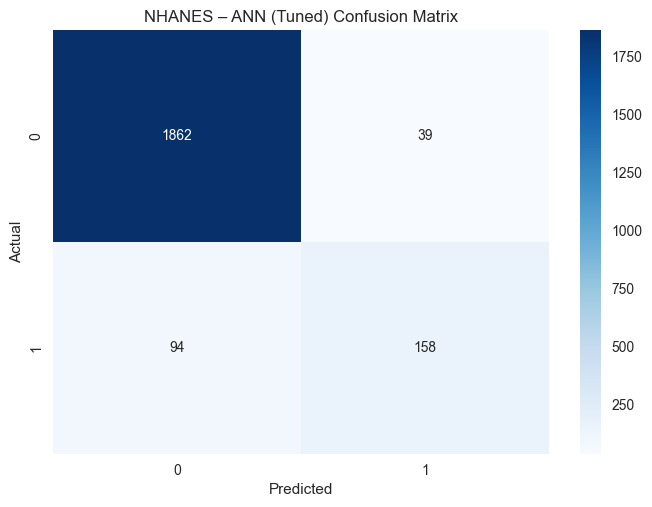

['../models/nhanes_ann_tuned.pkl']

In [60]:
ann_nh = MLPClassifier(
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

ann_param_dist_nh = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.0005],
    "batch_size": [32, 64, 128]
}

ann_search_nh = RandomizedSearchCV(
    ann_nh,
    ann_param_dist_nh,
    n_iter=20,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=42
)

ann_search_nh.fit(X_nhanes_train_scaled, y_nhanes_train)
best_ann_nh = ann_search_nh.best_estimator_
print("Best ANN params (NHANES):", ann_search_nh.best_params_)

results_nhanes_ann_tuned = evaluate_model(
    best_ann_nh,
    X_nhanes_test_scaled,
    y_nhanes_test,
    "NHANES – ANN (Tuned)"
)

joblib.dump(best_ann_nh, "../models/nhanes_ann_tuned.pkl")

## NHANES – Tuned Model Summary Table

In [61]:
nhanes_tuned_results = pd.DataFrame([
    results_nhanes_lr_tuned,
    results_nhanes_rf_tuned,
    results_nhanes_xgb_tuned,
    results_nhanes_ann_tuned
])

nhanes_tuned_results

,model,accuracy,f1,auc
0,NHANES – Logistic Regression (Tuned),0.884347,0.627803,0.943804
1,NHANES – Random Forest (Tuned),0.940548,0.719298,0.943994
2,NHANES – XGBoost (Tuned),0.940084,0.718954,0.946924
3,NHANES – ANN (Tuned),0.938226,0.703786,0.944217


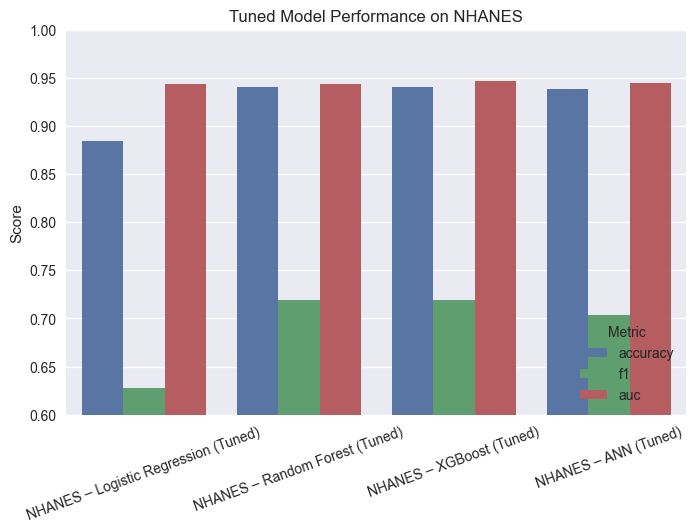

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select the metrics we want to plot
metrics_to_plot = ["accuracy", "f1", "auc"]

plot_df = nhanes_tuned_results[["model"] + metrics_to_plot].copy()

# 2. Convert to long format for seaborn (model, metric, score)
plot_long = plot_df.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score",
)

# 3. Clustered column chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=plot_long,
    x="model",
    y="score",
    hue="metric",
)

ax.set_ylim(0.6, 1.0)
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_title("Tuned Model Performance on NHANES")
plt.xticks(rotation=20)
plt.legend(title="Metric", loc="lower right")

# 4. Save for your thesis (Figure 4.20)
plt.savefig(
    "../figures/model_performance/fig_4_20_nhanes_tuned_models_clustered.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()